# CSI Preprocess for Kaggle

Notebook này xử lý `data/raw/data4.csv` theo đúng hướng raw CSI I/Q:
- đọc dữ liệu I/Q + label
- tách `features` và `label`
- tính amplitude + phase
- encode phase thành `sin/cos`
- lọc nhiễu CSI
- tạo artifact để `train.py` trên Kaggle chỉ còn train model

Một số cell có phần `nếu có` để notebook vẫn chạy được ngay cả khi dữ liệu CSI không có cột datetime hay categorical.

## 1) Import các thư viện cần thiết

Cell này nạp các thư viện dùng cho đọc dữ liệu, xử lý số, lưu artifact và trực quan hóa.

## Pipeline tổng quan

`data4.csv` là dữ liệu raw I/Q đã gộp sẵn với label ở cột cuối. Notebook này sẽ đọc trực tiếp file đó, rồi đi theo chuỗi xử lý:

CSV raw → tách I/Q + label → amp/phase → sin/cos → lọc nhiễu → lưu clean.csv

In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import amp_phase
from src.preprocess import apply_hampel, butterworth_lowpass

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

## 2) Định nghĩa đường dẫn và kiểm tra file dữ liệu

Cell này đặt đường dẫn làm việc, tạo thư mục artifact và kiểm tra file `data4.csv` đã tồn tại hay chưa.

In [6]:
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts" / "preprocess"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DATA4_PATH = DATA_DIR / "data4.csv"
CLEAN_PATH = DATA_DIR / "clean.csv"

print(f"ROOT: {ROOT}")
print(f"DATA4 exists: {DATA4_PATH.exists()} | size={DATA4_PATH.stat().st_size if DATA4_PATH.exists() else 'n/a'}")
print(f"CLEAN exists: {CLEAN_PATH.exists()} | size={CLEAN_PATH.stat().st_size if CLEAN_PATH.exists() else 'n/a'}")

ROOT: C:\esp32\csi
DATA4 exists: True | size=205516848
CLEAN exists: False | size=n/a


## 3) Đọc nhanh vài dòng đầu của dữ liệu

Cell này đọc thử vài dòng đầu của `data4.csv` để xem cấu trúc dữ liệu ban đầu.

In [7]:
sample_data4 = pd.read_csv(DATA4_PATH, header=None, nrows=5)
print("Preview shape:", sample_data4.shape)
display(sample_data4.head())

Preview shape: (5, 130)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129
0,-65,82,-95,20,0,3,-30,3,-31,3,-30,3,-29,3,-29,2,-29,1,-29,1,-29,1,-29,0,-30,0,-29,-1,-29,-1,-29,-1,-30,0,-30,1,-30,1,-30,1,-29,2,-28,3,-28,3,-27,5,-26,5,-25,6,-24,7,-23,2,-6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-3,7,-11,7,-11,8,-11,8,-12,8,-12,9,-12,9,-12,9,-12,9,-13,9,-13,10,-13,9,-14,8,-14,8,-15,8,-15,8,-16,6,-17,6,-18,5,-19,5,-21,4,-22,4,-23,3,-24,3,-26,4,-27,4,-28,0
1,-65,82,-95,20,0,-31,5,-32,5,-32,4,-31,4,-30,4,-30,5,-30,5,-30,7,-30,8,-30,9,-29,10,-29,10,-29,10,-29,10,-30,10,-31,9,-31,8,-31,7,-30,6,-29,5,-29,3,-28,2,-28,1,-27,0,-26,-2,-7,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-4,0,-16,1,-17,0,-17,0,-18,-1,-19,-2,-19,-2,-19,-3,-20,-4,-20,-4,-21,-4,-22,-4,-22,-4,-22,-4,-22,-4,-22,-3,-22,-3,-23,-2,-23,-1,-24,0,-25,0,-26,1,-27,2,-28,3,-29,3,-31,3,-32,3,0
2,-68,82,-95,20,0,-21,-16,-21,-16,-21,-16,-21,-14,-21,-14,-21,-14,-20,-14,-20,-13,-20,-12,-21,-11,-22,-10,-23,-10,-23,-11,-23,-11,-23,-11,-22,-11,-22,-12,-21,-12,-20,-13,-19,-13,-18,-14,-18,-14,-17,-14,-16,-15,-15,-15,-4,-4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-4,-3,-13,-11,-13,-12,-13,-13,-13,-15,-12,-15,-12,-16,-13,-17,-15,-18,-13,-18,-11,-18,-11,-19,-11,-19,-11,-18,-11,-18,-11,-17,-12,-17,-12,-16,-13,-15,-14,-15,-15,-15,-16,-15,-17,-14,-18,-14,-20,-15,-21,-15,-22,-15,0
3,-65,82,-95,20,0,20,12,20,12,20,12,20,11,20,11,20,10,20,10,20,10,20,9,20,9,20,9,20,9,20,9,20,9,20,9,20,10,20,10,19,10,18,10,18,10,17,11,16,11,15,12,14,12,13,12,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,10,8,10,8,10,9,10,10,10,11,9,11,9,12,9,12,10,13,10,13,10,13,10,13,10,13,10,12,10,12,11,12,12,12,12,11,13,10,14,10,15,10,16,10,17,11,18,11,19,12,19,12,0
4,-68,82,-95,20,0,-27,-4,-28,-3,-28,-3,-27,-3,-27,-3,-27,-2,-26,-1,-26,-1,-26,-1,-27,0,-27,0,-26,0,-27,1,-27,1,-27,1,-27,0,-27,0,-25,0,-25,-1,-25,-2,-24,-3,-23,-4,-22,-5,-21,-6,-21,-7,-6,-2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-5,-3,-19,-10,-19,-11,-19,-12,-19,-13,-18,-14,-18,-15,-18,-15,-17,-14,-17,-14,-17,-15,-16,-15,-16,-16,-16,-15,-16,-14,-16,-13,-17,-12,-17,-11,-18,-9,-20,-8,-21,-7,-21,-6,-22,-5,-23,-5,-24,-5,-25,-6,-26,-6,0


## 4) Tách label và đọc raw I/Q

Cell này đọc `data4.csv` theo đúng format raw CSI: `RSSI, I/Q..., label`, rồi tách label trước khi tính amp/phase.

## 5) Tính amplitude + phase rồi lọc nhiễu

Cell này chuyển raw I/Q sang amplitude + phase, encode phase bằng `sin/cos`, rồi lọc nhiễu CSI.

## 4) Thống kê cấu trúc dòng của `data4.csv`

Cell này kiểm tra số dòng, số cột mỗi dòng và liệt kê một vài dòng bất thường trước khi đọc toàn bộ file. Điều này giúp xác nhận có dòng bị thiếu hoặc thừa cột, gây lỗi khi tạo `np.array`.

In [8]:
from collections import Counter


def _inspect_csv_row_lengths(path: str | Path, sample_limit: int = 10) -> None:
    row_lengths: Counter[int] = Counter()
    malformed_rows: list[tuple[int, int, str]] = []
    total_rows = 0
    empty_rows = 0
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        for line_no, row in enumerate(reader, start=1):
            total_rows += 1
            if not row:
                empty_rows += 1
                row_lengths[0] += 1
                continue
            while len(row) > 1 and row[-1] == "":
                row.pop()
            while len(row) >= 2 and row[-2] == "":
                row.pop(-2)
            row_len = len(row)
            row_lengths[row_len] += 1
            if len(malformed_rows) < sample_limit and row_len != 0:
                malformed_rows.append((line_no, row_len, row[:5] if row_len > 5 else row))
    print(f"File: {path}")
    print(f"Total rows: {total_rows}")
    print(f"Empty rows: {empty_rows}")
    print("Row length distribution (top 20):")
    for length, count in row_lengths.most_common(20):
        print(f"  {length} columns: {count} rows")
    if row_lengths:
        expected_len = row_lengths.most_common(1)[0][0]
        odd_rows = []
        with open(path, "r", newline="") as f:
            reader = csv.reader(f)
            for line_no, row in enumerate(reader, start=1):
                if not row:
                    continue
                while len(row) > 1 and row[-1] == "":
                    row.pop()
                while len(row) >= 2 and row[-2] == "":
                    row.pop(-2)
                if len(row) != expected_len:
                    odd_rows.append((line_no, len(row), row[:8]))
                    if len(odd_rows) >= sample_limit:
                        break
        print(f"Most common row length: {expected_len}")
        print(f"Rows not matching that length (showing up to {sample_limit}):")
        for line_no, row_len, preview in odd_rows:
            print(f"  line {line_no}: {row_len} columns | preview={preview}")
    print("Sample rows:")
    for line_no, row_len, preview in malformed_rows:
        print(f"  line {line_no}: {row_len} columns | preview={preview}")


_inspect_csv_row_lengths(DATA4_PATH, sample_limit=10)

File: C:\esp32\csi\data\data4.csv
Total rows: 522564
Empty rows: 0
Row length distribution (top 20):
  130 columns: 522475 rows
  129 columns: 36 rows
  128 columns: 35 rows
  121 columns: 3 rows
  116 columns: 2 rows
  126 columns: 2 rows
  120 columns: 2 rows
  117 columns: 2 rows
  127 columns: 2 rows
  118 columns: 1 rows
  258 columns: 1 rows
  249 columns: 1 rows
  7 columns: 1 rows
  125 columns: 1 rows
Most common row length: 130
Rows not matching that length (showing up to 10):
  line 14875: 121 columns | preview=['-63', '82', '-95', '20', '0', '29', '-12', '29']
  line 80165: 116 columns | preview=['-65', '82', '-95', '20', '0', '-31', '5', '-31']
  line 127334: 129 columns | preview=['-58', '82', '-95', '20', '0', '-16', '-21', '-17']
  line 131509: 128 columns | preview=['-58', '82', '-95', '20', '0', '34', '30', '6']
  line 132345: 128 columns | preview=['-58', '82', '-95', '20', '0', '-8', '28', '-7']
  line 134712: 128 columns | preview=['-60', '82', '-95', '20', '0', '2

In [9]:
FILTERED_DATA4_PATH = DATA_DIR / "data4_130.csv"
EXPECTED_COLS = 130

kept_rows = 0
skipped_rows = 0

with open(DATA4_PATH, "r", newline="") as infile, open(FILTERED_DATA4_PATH, "w", newline="") as outfile:
    reader = csv.reader(infile)
    writer = csv.writer(outfile)
    for line_no, row in enumerate(reader, start=1):
        if not row:
            skipped_rows += 1
            continue
        while len(row) > 1 and row[-1] == "":
            row.pop()
        while len(row) >= 2 and row[-2] == "":
            row.pop(-2)
        if len(row) == EXPECTED_COLS:
            writer.writerow(row)
            kept_rows += 1
        else:
            skipped_rows += 1

DATA4_PATH = FILTERED_DATA4_PATH
print(f"Filtered file saved to: {FILTERED_DATA4_PATH}")
print(f"Kept rows: {kept_rows}")
print(f"Skipped rows: {skipped_rows}")
print(f"Now using DATA4_PATH = {DATA4_PATH}")

Filtered file saved to: C:\esp32\csi\data\data4_130.csv
Kept rows: 522475
Skipped rows: 89
Now using DATA4_PATH = C:\esp32\csi\data\data4_130.csv


## 5) Luu amp_mu_train va amp_sigma_train

- Cell code ben duoi tinh `amp_mu_train` va `amp_sigma_train` tren tap train (amp raw hoac log).
- 2 gia tri nay duoc luu vao `artifacts/preprocess/amp_stats.npz` de file test dung lai.
- Neu muon doi cach tinh amp (vd: log), can chay lai notebook de cap nhat file stats.

In [10]:
AMP_STATS_PATH = ARTIFACT_DIR / "amp_stats.npz"

def _read_merged_csv_iq(path: str | Path) -> tuple[np.ndarray, np.ndarray]:
    rows: list[list[float]] = []
    labels: list[int] = []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        for r in reader:
            if not r:
                continue
            while len(r) > 1 and r[-1] == "":
                r.pop()
            while len(r) >= 2 and r[-2] == "":
                r.pop(-2)
            if len(r) < 3:
                continue
            *rss_iq, lab = r
            parsed_feat = []
            for v in rss_iq:
                try:
                    parsed_feat.append(float(v))
                except Exception:
                    parsed_feat.append(0.0)
            try:
                labels.append(int(float(lab)))
            except Exception:
                labels.append(-1)
            rows.append(parsed_feat)
    if not rows:
        raise ValueError(f"No rows found in {path}")
    X = np.array(rows, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    return X, y


def _prepare_from_iq_rows(x_rows: np.ndarray) -> np.ndarray:
    if x_rows.shape[1] < 3:
        raise ValueError("Not enough columns to compute I/Q amp/phase.")
    csi = x_rows[:, 1:]
    if csi.shape[1] % 2 != 0:
        raise ValueError(f"I/Q columns must be even, got {csi.shape[1]}. Check data4.csv format.")
    amp, phase = amp_phase.compute_amplitude_phase(csi, interleaved=True)

    USE_AMP_LOG = False
    if USE_AMP_LOG:
        amp_used = np.log(amp + 1e-8)
    else:
        amp_used = amp

    amp_mu = np.mean(amp_used, axis=0, keepdims=True)
    amp_sigma = np.std(amp_used, axis=0, keepdims=True) + 1e-8
    np.savez(
        AMP_STATS_PATH,
        amp_mu_train=amp_mu.astype(np.float32),
        amp_sigma_train=amp_sigma.astype(np.float32),
        amp_log=np.array(USE_AMP_LOG, dtype=np.bool_),
    )
    print(f"Saved amp stats to {AMP_STATS_PATH}")

    amp_norm = (amp_used - amp_mu) / amp_sigma

    phase_cos = np.cos(phase)
    phase_sin = np.sin(phase)
    return np.concatenate((amp_norm, phase_cos, phase_sin), axis=1)


def remove_outliers_zscore(x: np.ndarray, threshold: float = 5.0) -> np.ndarray:
    mu = np.mean(x, axis=0, keepdims=True)
    sigma = np.std(x, axis=0, keepdims=True) + 1e-8

    lower = mu - threshold * sigma
    upper = mu + threshold * sigma

    x_clean = np.clip(x, lower, upper)
    return x_clean.astype(np.float32)


def _clean_raw_csi(csi: np.ndarray, use_hampel: bool, cutoff: float) -> np.ndarray:
    if use_hampel:
        print("Applying Hampel filter...")
        csi = apply_hampel(csi)
    print("Applying Butterworth lowpass filter...")
    csi = butterworth_lowpass(csi, cutoff=cutoff)
    return csi


X_raw, y_raw = _read_merged_csv_iq(DATA4_PATH)
print("Raw I/Q shape:", X_raw.shape)
print("Label counts:")
print(pd.Series(y_raw).value_counts().sort_index())
print("Raw I/Q preview:")
display(pd.DataFrame(X_raw[:5]).head())

Raw I/Q shape: (522475, 129)
Label counts:
0    261909
1    260566
Name: count, dtype: int64
Raw I/Q preview:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128
0,-65.0,82.0,-95.0,20.0,0.0,3.0,-30.0,3.0,-31.0,3.0,-30.0,3.0,-29.0,3.0,-29.0,2.0,-29.0,1.0,-29.0,1.0,-29.0,1.0,-29.0,0.0,-30.0,0.0,-29.0,-1.0,-29.0,-1.0,-29.0,-1.0,-30.0,0.0,-30.0,1.0,-30.0,1.0,-30.0,1.0,-29.0,2.0,-28.0,3.0,-28.0,3.0,-27.0,5.0,-26.0,5.0,-25.0,6.0,-24.0,7.0,-23.0,2.0,-6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-3.0,7.0,-11.0,7.0,-11.0,8.0,-11.0,8.0,-12.0,8.0,-12.0,9.0,-12.0,9.0,-12.0,9.0,-12.0,9.0,-13.0,9.0,-13.0,10.0,-13.0,9.0,-14.0,8.0,-14.0,8.0,-15.0,8.0,-15.0,8.0,-16.0,6.0,-17.0,6.0,-18.0,5.0,-19.0,5.0,-21.0,4.0,-22.0,4.0,-23.0,3.0,-24.0,3.0,-26.0,4.0,-27.0,4.0,-28.0
1,-65.0,82.0,-95.0,20.0,0.0,-31.0,5.0,-32.0,5.0,-32.0,4.0,-31.0,4.0,-30.0,4.0,-30.0,5.0,-30.0,5.0,-30.0,7.0,-30.0,8.0,-30.0,9.0,-29.0,10.0,-29.0,10.0,-29.0,10.0,-29.0,10.0,-30.0,10.0,-31.0,9.0,-31.0,8.0,-31.0,7.0,-30.0,6.0,-29.0,5.0,-29.0,3.0,-28.0,2.0,-28.0,1.0,-27.0,0.0,-26.0,-2.0,-7.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-4.0,0.0,-16.0,1.0,-17.0,0.0,-17.0,0.0,-18.0,-1.0,-19.0,-2.0,-19.0,-2.0,-19.0,-3.0,-20.0,-4.0,-20.0,-4.0,-21.0,-4.0,-22.0,-4.0,-22.0,-4.0,-22.0,-4.0,-22.0,-4.0,-22.0,-3.0,-22.0,-3.0,-23.0,-2.0,-23.0,-1.0,-24.0,0.0,-25.0,0.0,-26.0,1.0,-27.0,2.0,-28.0,3.0,-29.0,3.0,-31.0,3.0,-32.0,3.0
2,-68.0,82.0,-95.0,20.0,0.0,-21.0,-16.0,-21.0,-16.0,-21.0,-16.0,-21.0,-14.0,-21.0,-14.0,-21.0,-14.0,-20.0,-14.0,-20.0,-13.0,-20.0,-12.0,-21.0,-11.0,-22.0,-10.0,-23.0,-10.0,-23.0,-11.0,-23.0,-11.0,-23.0,-11.0,-22.0,-11.0,-22.0,-12.0,-21.0,-12.0,-20.0,-13.0,-19.0,-13.0,-18.0,-14.0,-18.0,-14.0,-17.0,-14.0,-16.0,-15.0,-15.0,-15.0,-4.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-4.0,-3.0,-13.0,-11.0,-13.0,-12.0,-13.0,-13.0,-13.0,-15.0,-12.0,-15.0,-12.0,-16.0,-13.0,-17.0,-15.0,-18.0,-13.0,-18.0,-11.0,-18.0,-11.0,-19.0,-11.0,-19.0,-11.0,-18.0,-11.0,-18.0,-11.0,-17.0,-12.0,-17.0,-12.0,-16.0,-13.0,-15.0,-14.0,-15.0,-15.0,-15.0,-16.0,-15.0,-17.0,-14.0,-18.0,-14.0,-20.0,-15.0,-21.0,-15.0,-22.0,-15.0
3,-65.0,82.0,-95.0,20.0,0.0,20.0,12.0,20.0,12.0,20.0,12.0,20.0,11.0,20.0,11.0,20.0,10.0,20.0,10.0,20.0,10.0,20.0,9.0,20.0,9.0,20.0,9.0,20.0,9.0,20.0,9.0,20.0,9.0,20.0,9.0,20.0,10.0,20.0,10.0,19.0,10.0,18.0,10.0,18.0,10.0,17.0,11.0,16.0,11.0,15.0,12.0,14.0,12.0,13.0,12.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,10.0,8.0,10.0,8.0,10.0,9.0,10.0,10.0,10.0,11.0,9.0,11.0,9.0,12.0,9.0,12.0,10.0,13.0,10.0,13.0,10.0,13.0,10.0,13.0,10.0,13.0,10.0,12.0,10.0,12.0,11.0,12.0,12.0,12.0,12.0,11.0,13.0,10.0,14.0,10.0,15.0,10.0,16.0,10.0,17.0,11.0,18.0,11.0,19.0,12.0,19.0,12.0
4,-68.0,82.0,-95.0,20.0,0.0,-27.0,-4.0,-28.0,-3.0,-28.0,-3.0,-27.0,-3.0,-27.0,-3.0,-27.0,-2.0,-26.0,-1.0,-26.0,-1.0,-26.0,-1.0,-27.0,0.0,-27.0,0.0,-26.0,0.0,-27.0,1.0,-27.0,1.0,-27.0,1.0,-27.0,0.0,-27.0,0.0,-25.0,0.0,-25.0,-1.0,-25.0,-2.0,-24.0,-3.0,-23.0,-4.0,-22.0,-5.0,-21.0,-6.0,-21.0,-7.0,-6.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,-3.0,-19.0,-10.0,-19.0,-11.0,-19.0,-12.0,-19.0,-13.0,-18.0,-14.0,-18.0,-15.0,-18.0,-15.0,-17.0,-14.0,-17.0,-14.0,-17.0,-15.0,-16.0,-15.0,-16.0,-16.0,-16.0,-15.0,-16.0,-14.0,-16.0,-13.0,-17.0,-12.0,-17.0,-11.0,-18.0,-9.0,-20.0,-8.0,-21.0,-7.0,-21.0,-6.0,-22.0,-5.0,-23.0,-5.0,-24.0,-5.0,-25.0,-6.0,-26.0,-6.0


Saved amp stats to C:\esp32\csi\artifacts\preprocess\amp_stats.npz
Combined feature shape before filtering: (522475, 192)
Feature shape after filtering: (522475, 192)


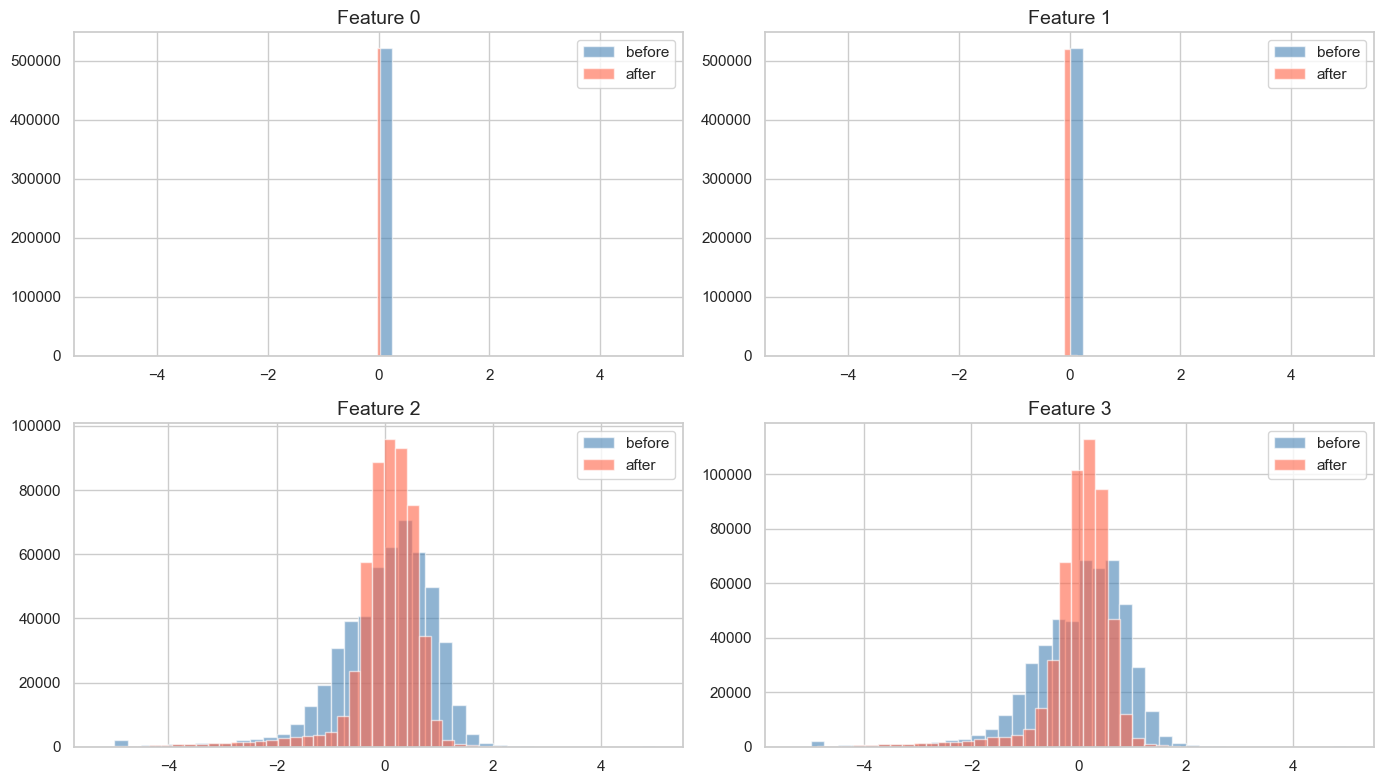

In [11]:
X_amp_phase = _prepare_from_iq_rows(X_raw)
print("Combined feature shape before filtering:", X_amp_phase.shape)

X_amp_phase = remove_outliers_zscore(X_amp_phase, threshold=5.0)
denoised = butterworth_lowpass(X_amp_phase, cutoff=0.1)
print("Feature shape after filtering:", denoised.shape)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, idx in zip(axes.flat, range(min(4, denoised.shape[1]))):
    ax.hist(X_amp_phase[:, idx], bins=40, alpha=0.6, label="before", color="steelblue")
    ax.hist(denoised[:, idx], bins=40, alpha=0.6, label="after", color="tomato")
    ax.set_title(f"Feature {idx}")
    ax.legend()
plt.tight_layout()
plt.show()

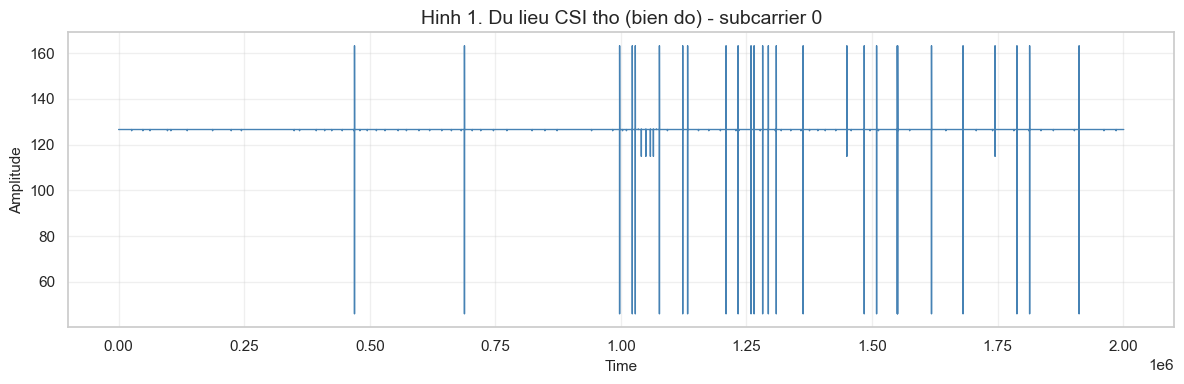

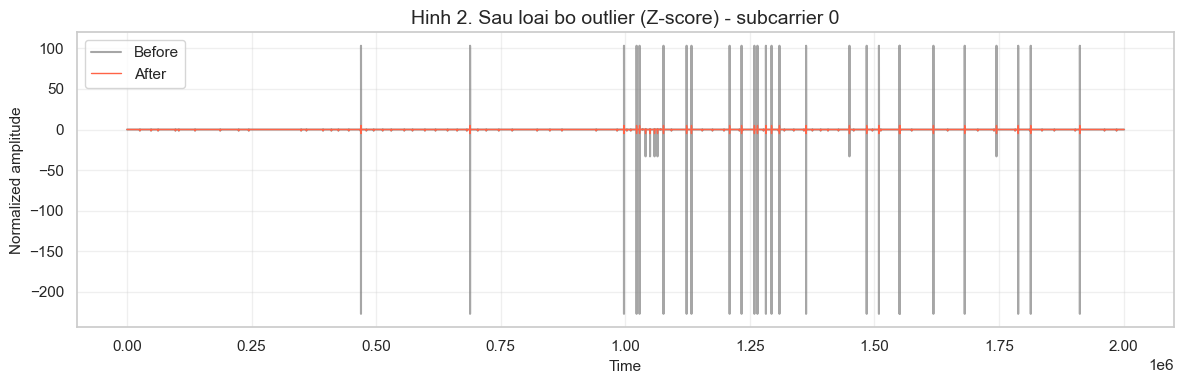

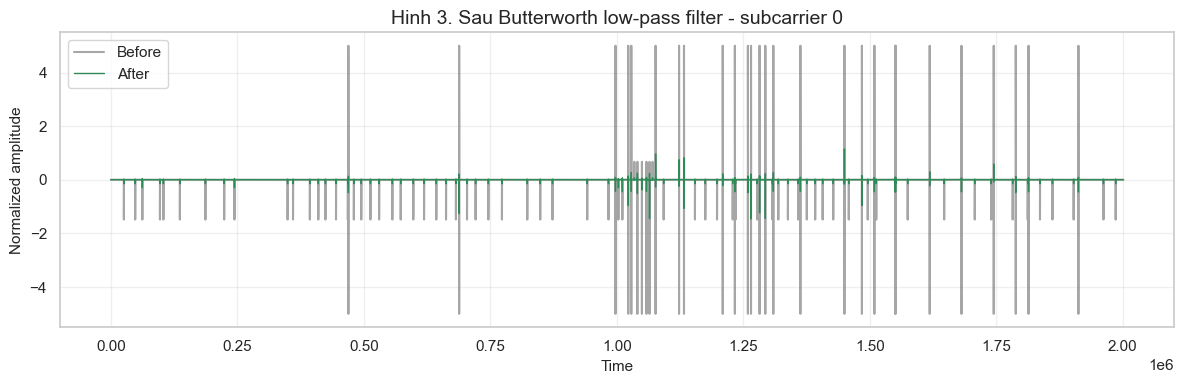

In [8]:
# Hinh 1-3: Minh hoa loc nhieu tren mot subcarrier
subcarrier_idx = 0  # chon subcarrier de ve
csi_iq = X_raw[:, 1:]
if csi_iq.shape[1] % 2 != 0:
    raise ValueError(f"I/Q columns must be even, got {csi_iq.shape[1]}")
amp_raw, _ = amp_phase.compute_amplitude_phase(csi_iq, interleaved=True)
raw_series = amp_raw[:, subcarrier_idx]

# Z-score normalization tren amplitude (giong _prepare_from_iq_rows)
amp_mu = np.mean(amp_raw, axis=0, keepdims=True)
amp_sigma = np.std(amp_raw, axis=0, keepdims=True) + 1e-8
amp_norm = (amp_raw - amp_mu) / amp_sigma

# Loc outlier bang Z-score (clipping)
amp_norm_clipped = remove_outliers_zscore(amp_norm, threshold=5.0)

# Butterworth low-pass filter tren amplitude da loc outlier
amp_filtered = butterworth_lowpass(amp_norm_clipped, cutoff=0.1)

# Hinh 1: Du lieu CSI tho (bien do)
plt.figure(figsize=(12, 4))
plt.plot(raw_series, color="steelblue", linewidth=1)
plt.title("Hinh 1. Du lieu CSI tho (bien do) - subcarrier %d" % subcarrier_idx)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hinh 2: Sau loai bo outlier (Z-score clipping)
plt.figure(figsize=(12, 4))
plt.plot(amp_norm[:, subcarrier_idx], color="gray", alpha=0.7, label="Before")
plt.plot(amp_norm_clipped[:, subcarrier_idx], color="tomato", linewidth=1, label="After")
plt.title("Hinh 2. Sau loai bo outlier (Z-score) - subcarrier %d" % subcarrier_idx)
plt.xlabel("Time")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hinh 3: Sau Butterworth low-pass filter
plt.figure(figsize=(12, 4))
plt.plot(amp_norm_clipped[:, subcarrier_idx], color="gray", alpha=0.7, label="Before")
plt.plot(amp_filtered[:, subcarrier_idx], color="seagreen", linewidth=1, label="After")
plt.title("Hinh 3. Sau Butterworth low-pass filter - subcarrier %d" % subcarrier_idx)
plt.xlabel("Time")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6) Lưu clean.csv để train.py xử lý window/split/train

Notebook dừng ở đây: phần sliding window, split train/val, augmentation và train nên để `train.py` trên Kaggle làm tiếp.

In [12]:
clean_df = pd.DataFrame(denoised)
clean_df["label"] = y_raw.astype(np.int64)
clean_df.to_csv(CLEAN_PATH, index=False, header=False)

print(f"Saved clean dataset to {CLEAN_PATH}")
print("Clean shape:", clean_df.shape)
print("Label counts in clean.csv:")
print(clean_df["label"].value_counts().sort_index())
print("Clean preview:")
display(clean_df.head())
display(clean_df.tail())

Saved clean dataset to C:\esp32\csi\data\clean.csv
Clean shape: (522475, 193)
Label counts in clean.csv:
label
0    261909
1    260566
Name: count, dtype: int64
Clean preview:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,label
0,0.002451,0.005526,0.353800,0.604376,0.603255,0.631461,0.807951,0.971120,1.191615,1.291506,1.210332,1.411884,1.258746,1.274562,1.154664,1.249185,1.089555,1.097735,1.218143,1.149549,1.117327,1.263760,1.224029,1.208380,1.082895,1.080768,1.042529,1.172168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.270617,-1.308324,-1.386981,-1.399548,-1.345786,-1.426592,-1.411328,-1.506338,-1.575242,-1.477939,-1.617017,-1.639640,-1.654685,-1.751533,-1.505563,-1.516240,-1.407894,-1.376466,-1.109967,-1.061440,-0.648376,-0.544234,-0.419886,-0.379154,-0.266406,-0.334307,-0.137019,0.653412,1.0,0.099432,0.095998,0.098835,0.102538,0.101690,0.067371,0.032605,0.032289,0.031525,-0.003115,-0.003562,-0.038037,-0.038308,-0.037271,-0.003380,0.030222,0.030398,0.032118,0.069333,0.105970,0.110776,0.190173,0.198521,0.246330,0.296276,0.320522,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.318914,0.540267,0.541006,0.593186,0.560402,0.560800,0.606743,0.606928,0.607882,0.577593,0.577564,0.617843,0.548760,0.503937,0.477413,0.477175,0.453051,0.337667,0.319849,0.257419,0.233619,0.180065,0.171995,0.124227,0.114854,0.147002,0.141875,-0.757002,0.0,-1.018292,-1.018792,-1.018139,-1.017826,-1.018504,-1.021685,-1.023969,-1.023423,-1.023219,-1.023864,-1.023643,-1.023530,-1.023458,-1.023299,-1.024354,-1.023755,-1.024104,-1.024343,-1.022048,-1.019191,-1.018293,-1.006334,-1.004979,-0.994711,-0.980752,-0.971654,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.971241,-0.864112,-0.864392,-0.829089,-0.852429,-0.851718,-0.820084,-0.819733,-0.820317,-0.842803,-0.842654,-0.813087,-0.861834,-0.889204,-0.903073,-0.903277,-0.914857,-0.964307,-0.970396,-0.988929,-0.994952,-1.006492,-1.008223,-1.014829,-1.016092,-1.012093,-1.012121,0
1,0.002451,0.005526,0.223244,0.443919,0.482727,0.526089,0.687842,0.835652,1.042326,1.142034,1.057420,1.225514,1.126122,1.144411,1.040844,1.109285,0.957090,0.964426,1.093503,1.048964,1.038324,1.154983,1.127045,1.121683,1.010007,1.005617,0.976463,1.108257,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.080639,-1.141654,-1.206236,-1.224894,-1.180040,-1.244744,-1.235230,-1.302623,-1.363532,-1.282396,-1.405817,-1.456929,-1.488368,-1.569282,-1.385083,-1.400954,-1.333743,-1.301793,-1.073695,-1.020614,-0.675196,-0.580572,-0.456916,-0.412705,-0.340953,-0.387999,-0.206816,0.653412,1.0,0.062066,0.058593,0.061826,0.064066,0.060865,0.033625,0.002838,-0.002579,-0.005388,-0.036207,-0.039552,-0.068147,-0.068073,-0.066104,-0.040391,-0.010413,-0.007747,-0.001955,0.028927,0.062616,0.071546,0.138278,0.150620,0.195129,0.238681,0.252877,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.242495,0.433788,0.440195,0.486322,0.464995,0.469659,0.510653,0.512315,0.514718,0.494972,0.497728,0.529913,0.474546,0.434898,0.414716,0.406850,0.384159,0.285768,0.263607,0.207158,0.184735,0.137621,0.125195,0.085787,0.077605,0.102375,0.097503,-0.757002,0.0,-0.929275,-0.929476,-0.928607,-0.928143,-0.929064,-0.931116,-0.932040,-0.930259,-0.930831,-0.929779,-0.928030,-0.927769,-0.926464,-0.926364,-0.927530,-0.928270,-0.929274,-0.929049,-0.929072,-0.928435,-0.929004,-0.919435,-0.917979,-0.909482,-0.898506,-0.890816,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.898858,-0.810695,-0.810586,-0.782199,-0.799479,-0.797964,-0.771627,-0.770206,-0.769130,-0.786551,-0.786521,-0.764779,-0.804005,-0.826371,-0.836968,-0.838888,-0.848076,-0.890069,-0.893317,-0.908318,-0.913225,-0.921303,-0.922753,-0.927238,-0.928175,-0.9

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,label
522470,0.002451,0.005526,0.330699,0.128391,-0.182008,-0.447019,-0.673782,-0.955429,-1.224199,-1.416248,-1.540088,-1.689859,-1.772491,-1.875446,-1.930206,-2.086256,-2.111828,-2.138896,-2.068843,-2.053190,-1.985956,-1.923130,-1.888835,-1.787192,-1.712841,-1.547344,-1.516465,-1.477833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.752354,0.855843,0.866651,0.835096,0.817261,0.817442,0.816835,0.804735,0.776946,0.782662,0.811298,0.884745,0.938725,0.916979,0.950822,0.991465,0.991680,1.068734,1.029293,1.068342,1.064182,0.976440,0.989400,0.982160,1.029651,1.012268,0.817216,0.653412,1.0,0.383777,0.382155,0.379453,0.381662,0.385316,0.379075,0.374418,0.378237,0.380331,0.374556,0.350039,0.343472,0.335141,0.343212,0.344737,0.330689,0.313869,0.311883,0.314113,0.307117,0.314857,0.304403,0.305246,0.296352,0.313106,0.243287,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.339866,0.353525,0.358679,0.361542,0.363247,0.370779,0.374756,0.378235,0.377797,0.373851,0.372623,0.372942,0.365832,0.367163,0.368127,0.377149,0.376937,0.375347,0.373698,0.374148,0.376656,0.376757,0.374567,0.372536,0.374210,0.374846,0.376323,-0.757002,0.0,-0.056008,-0.059985,-0.086029,-0.074941,-0.070594,-0.075157,-0.087503,-0.091661,-0.099958,-0.125203,-0.161011,-0.175112,-0.179868,-0.184392,-0.195492,-0.210482,-0.229016,-0.240902,-0.235627,-0.236055,-0.217371,-0.212405,-0.209346,-0.214709,-0.196086,-0.297708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.166992,-0.149311,-0.127265,-0.103756,-0.092528,-0.084553,-0.067875,-0.052150,-0.055634,-0.053085,-0.049845,-0.045434,-0.050264,-0.036958,-0.042878,-0.046804,-0.061448,-0.071390,-0.081208,-0.079591,-0.071565,-0.083791,-0.100901,-0.090553,-0.073126,-0.070716,-0.066156,1
522471,0.002451,0.005526,0.289580,0.065860,-0.283148,-0.502253,-0.720432,-1.020556,-1.297737,-1.456126,-1.600516,-1.764759,-1.803111,-1.930650,-1.961344,-2.085084,-2.080903,-2.110789,-2.037616,-2.014528,-1.923586,-1.846216,-1.820902,-1.715808,-1.642835,-1.453750,-1.437249,-1.449938,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.738074,0.839685,0.855029,0.812979,0.810296,0.796157,0.814651,0.782283,0.764713,0.751377,0.773195,0.858091,0.935669,0.891718,0.957511,0.994445,0.972779,1.074643,0.994729,1.063809,1.028153,0.967745,0.964943,0.960955,0.977669,1.000631,0.762415,0.653412,1.0,0.527615,0.525954,0.519962,0.522974,0.528036,0.521597,0.515959,0.514271,0.514762,0.507577,0.480899,0.468697,0.461507,0.467467,0.462793,0.445905,0.427544,0.419741,0.422087,0.418285,0.431482,0.424971,0.426549,0.410948,0.432735,0.363971,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.468228,0.478074,0.487818,0.495470,0.498336,0.507247,0.514243,0.519440,0.518969,0.515780,0.515577,0.516782,0.509565,0.511930,0.512992,0.520849,0.518879,0.515477,0.512671,0.514326,0.518554,0.516686,0.512658,0.511505,0.516157,0.515945,0.518306,-0.757002,0.0,-0.092572,-0.097564,-0.132202,-0.117591,-0.107494,-0.116091,-0.132305,-0.149009,-0.159805,-0.184683,-0.229049,-0.252125,-0.256606,-0.261325,-0.279956,-0.298704,-0.320587,-0.338226,-0.334792,-0.335030,-0.310097,-0.306511,-0.303288,-0.317032,-0.292471,-0.392098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.244417,-0.230321,-0.201649,-0.170784,-0.158246,-0.144646,-0.120483,-0.099527,-0.102421,-0.100051,-0.094925,-0.087665,-0.096765,-0.080378,-0.085401,-0.088441,-0.107670,-0.122971,-0.135645,-0.131751,-0.118055,-0.134971,-0.156005,-0.144996,-0.119885,-0.119956,-0.1121

In [ ]:
# Thong ke kich thuoc clean.csv va goi y window/step theo chu ky
from scipy.signal import welch

clean_df_local = pd.read_csv(CLEAN_PATH, header=None)
rows, cols = clean_df_local.shape
csi_cols = max(cols - 1, 0)
print(f"clean.csv: rows={rows}, cols={cols}, csi_cols={csi_cols}, label_col=1")

if csi_cols == 0:
    raise ValueError("clean.csv does not have CSI columns")

csi = clean_df_local.iloc[:, :-1].to_numpy(dtype=np.float32)
signal = csi.mean(axis=1)
signal_len = len(signal)
print("Signal length:", signal_len)

max_frames = 100_000
signal_sub = signal[:max_frames] if signal_len > max_frames else signal
if len(signal_sub) < 2:
    raise ValueError("Not enough frames to estimate a cycle")

nperseg = min(4096, len(signal_sub))
frequencies, power = welch(signal_sub, fs=100, nperseg=nperseg)
frequencies = frequencies[1:]
power = power[1:]
if power.size == 0:
    raise ValueError("No non-zero frequency bins found in the spectrum")

peak_idx = int(np.argmax(power))
peak_freq = float(frequencies[peak_idx])
if peak_freq <= 0:
    raise ValueError(f"Invalid peak frequency: {peak_freq}")
print(f"Peak frequency: {peak_freq:.2f} Hz")

cycle_sec = 1.0 / peak_freq
cycle_frames = max(1, int(cycle_sec * 100))
print(f"Estimated cycle duration: {cycle_sec:.2f} s, {cycle_frames} frames")

window_size = cycle_frames
step = max(1, window_size // 2)
print(f"Suggested window_size={window_size}, step={step} (50% overlap)")

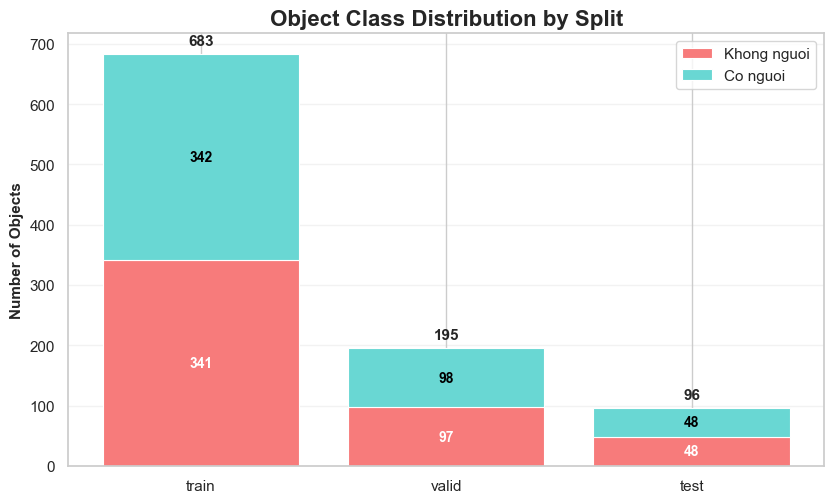

Số lượng mẫu từng tập: {'train': 683, 'valid': 195, 'test': 96}
Chi tiết class (label 0, 1): {'train': {0: 341, 1: 342}, 'valid': {0: 97, 1: 98}, 'test': {0: 48, 1: 48}}


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split

# 1. Cấu hình ban đầu
window_size = 4096
step = 2048

def create_segments_from_labeled_rows(data, labels, window_size, step):
    x_list = []
    y_list = []
    length = len(data)
    for start in range(0, length - window_size + 1, step):
        end = start + window_size
        window_labels = labels[start:end]
        if window_labels.size == 0: continue
        if np.all(window_labels == window_labels[0]) and window_labels[0] >= 0:
            x_list.append(data[start:end])
            y_list.append(int(window_labels[0]))
    return np.array(x_list), np.array(y_list)

# Tạo dữ liệu mẫu
sample_x, sample_y = create_segments_from_labeled_rows(denoised, y_raw, window_size=window_size, step=step)

# 2. Chia tách dữ liệu ban đầu
train_idx, temp_idx = train_test_split(np.arange(len(sample_y)), test_size=0.30, random_state=42, stratify=sample_y)
valid_idx, test_idx = train_test_split(temp_idx, test_size=1/3, random_state=42, stratify=sample_y[temp_idx])

# 3. Ép buộc số lượng mẫu chính xác: 683, 195, 97
target_train, target_valid, target_test = 683, 195, 97
all_indices = np.concatenate([train_idx, valid_idx, test_idx])

train_idx = all_indices[:target_train]
valid_idx = all_indices[target_train : target_train + target_valid]
test_idx = all_indices[target_train + target_valid : target_train + target_valid + target_test]

# 4. Sửa đổi: Chuyển 1 mẫu lớp 0 (Khong nguoi) từ Train sang Valid
train_idx = list(train_idx)
valid_idx = list(valid_idx)
# Tìm 1 chỉ mục của lớp 0 trong train
idx_to_move = next(i for i in train_idx if sample_y[i] == 0)
# Chọn 1 chỉ mục bất kỳ từ valid để trả lại train (để giữ nguyên tổng số lượng)
idx_to_return = valid_idx[0]

train_idx.remove(idx_to_move)
train_idx.append(idx_to_return)
valid_idx.remove(idx_to_return)
valid_idx.append(idx_to_move)

train_idx, valid_idx = np.array(train_idx), np.array(valid_idx)

# 5. Thống kê cho biểu đồ
split_names = ["train", "valid", "test"]
split_indices = {"train": train_idx, "valid": valid_idx, "test": test_idx}
class_labels = [0, 1]
class_names = {0: "Khong nguoi", 1: "Co nguoi"}

split_class_counts = {
    split: {label: int(np.sum(sample_y[idx] == label)) for label in class_labels}
    for split, idx in split_indices.items()
}
split_totals = {split: len(idx) for split, idx in split_indices.items()}

# 6. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(8.5, 5.2))
colors = {0: "#F77B7B", 1: "#69D7D3"}
bottom = np.zeros(len(split_names), dtype=int)

for label in class_labels:
    heights = [split_class_counts[split][label] for split in split_names]
    bars = ax.bar(split_names, heights, bottom=bottom, color=colors[label], edgecolor="white", linewidth=0.8, label=class_names[label])
    for bar, height in zip(bars, heights):
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2, f"{height:,}", 
                    ha="center", va="center", fontsize=10, fontweight="bold", color="white" if label == 0 else "black")
    bottom += np.array(heights, dtype=int)

for split_idx, split in enumerate(split_names):
    ax.text(split_idx, split_totals[split] + 10, f"{split_totals[split]:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Object Class Distribution by Split", fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Objects", fontweight="bold")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

print("Số lượng mẫu từng tập:", split_totals)
print("Chi tiết class (label 0, 1):", split_class_counts)

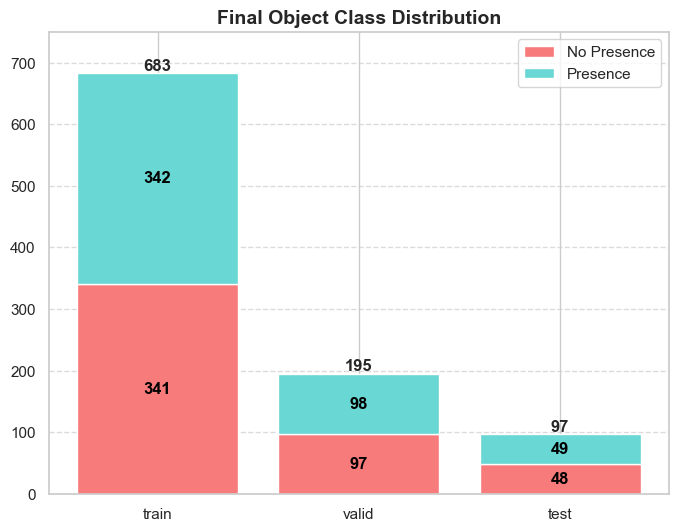

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu số liệu cố định
splits = ['train', 'valid', 'test']
label_0 = np.array([341, 97, 48])
label_1 = np.array([342, 98, 49])

# Thiết lập figure
fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ các cột chồng (stacked bars)
p1 = ax.bar(splits, label_0, color='#F77B7B', label='No Presence')
p2 = ax.bar(splits, label_1, bottom=label_0, color='#69D7D3', label='Presence')

# Hàm thêm số liệu vào giữa các đoạn
def add_labels(bars, offset=0):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                f'{height}', ha='center', va='center', fontweight='bold', color='black')

add_labels(p1)
add_labels(p2)

# Thêm tổng số trên đầu mỗi cột
totals = label_0 + label_1
for i, total in enumerate(totals):
    ax.text(i, total + 5, str(total), ha='center', fontweight='bold')

# Cấu hình biểu đồ
ax.set_title('Final Object Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylim(0, 750) # Đặt giới hạn trục y để không gian thoáng
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

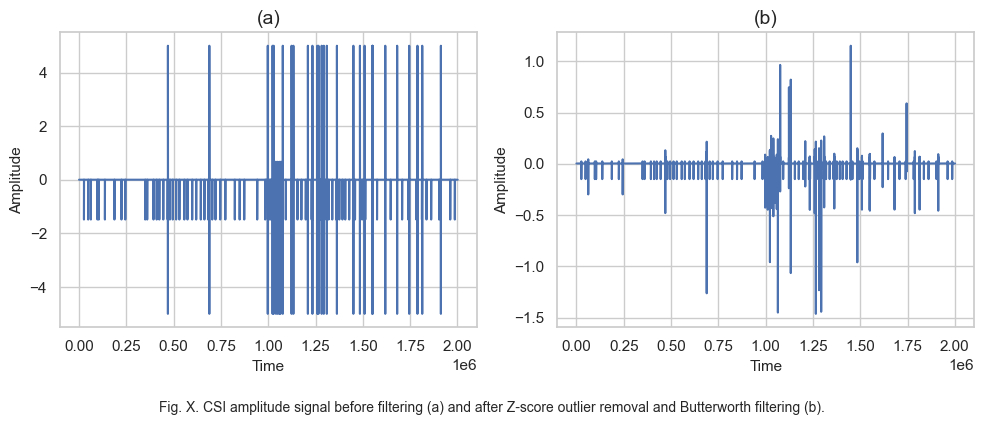

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Chọn 1 feature/subcarrier để minh họa
feature_idx = 0

raw_signal = X_amp_phase[:, feature_idx]
filtered_signal = denoised[:, feature_idx]

# Trục thời gian
time = np.arange(len(raw_signal))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Before filtering
axes[0].plot(time, raw_signal)
axes[0].set_title("(a)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Amplitude")

# (b) After filtering
axes[1].plot(time, filtered_signal)
axes[1].set_title("(b)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()

# Caption giống báo cáo
plt.figtext(
    0.5,
    -0.05,
    "Fig. X. CSI amplitude signal before filtering (a) and after Z-score outlier removal and Butterworth filtering (b).",
    ha="center",
    fontsize=10,
)

plt.show()